In [2]:
import pandas as pd
data=pd.read_csv('customer_churn.csv')
df=pd.DataFrame(data)
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

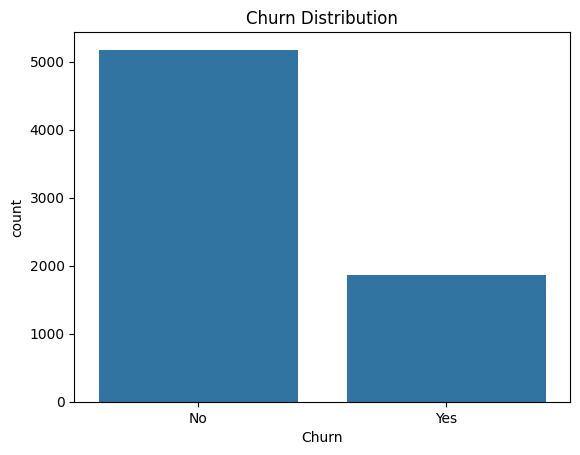

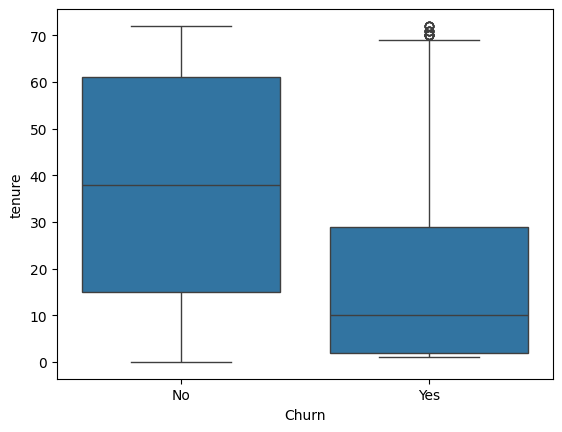

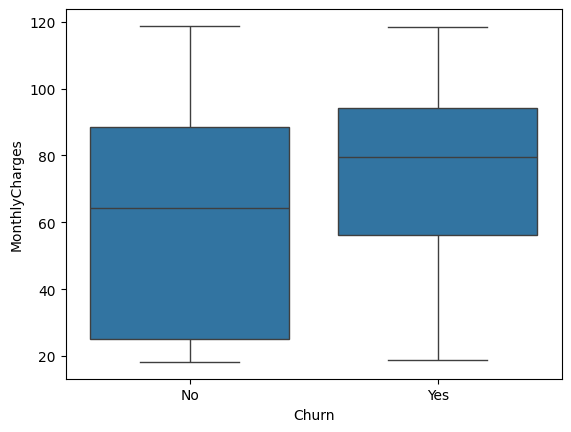

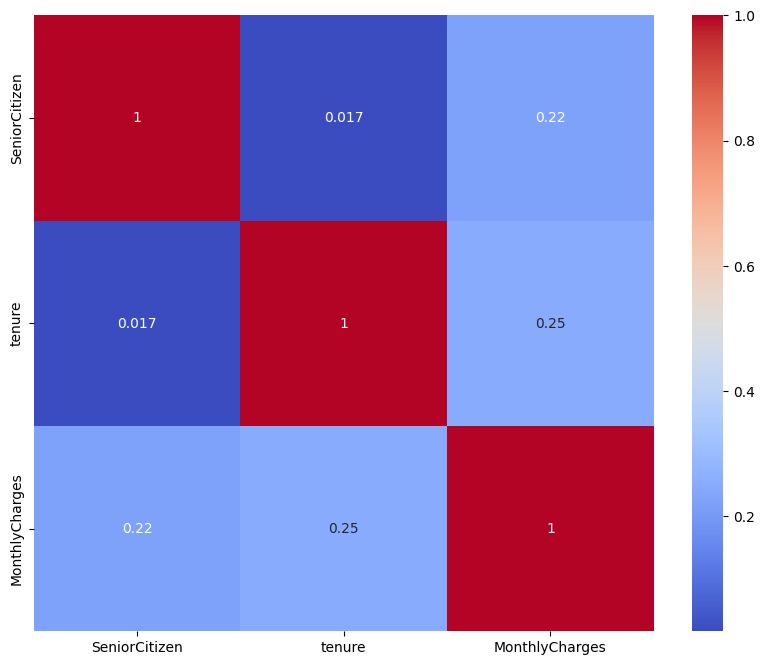

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn distribution
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

# Numerical features vs churn
sns.boxplot(x='Churn', y='tenure', data=data)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [4]:
num_col=[]
cat_col=[]
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.fillna({'TotalCharges': data['TotalCharges'].mode()[0]}, inplace=True)
for i in data.columns:
    if data[i].dtype in ['int64','float64']:
        num_col.append(i)
    else :
        cat_col.append(i)
print(num_col)
print(cat_col)


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [5]:
Num_features=['tenure', 'MonthlyCharges', 'TotalCharges']
Cat_features=['PhoneService','MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
               'Contract', 'PaperlessBilling', 'PaymentMethod']

In [6]:
from sklearn.preprocessing import OneHotEncoder
my_encoder=OneHotEncoder(sparse_output=False)
encoded_data=my_encoder.fit_transform(data[Cat_features])
encoded_df = pd.DataFrame(encoded_data, columns=my_encoder.get_feature_names_out(Cat_features))
encoded_df.index = data.index
final_data = pd.concat([data[Num_features], encoded_df], axis=1)
final_data.head()


,tenure,MonthlyCharges,TotalCharges,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,34,56.95,1889.50,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,53.85,108.15,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,45,42.30,1840.75,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,2,70.70,151.65,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_data)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

X=X_scaled
y = data['Churn'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

my_models={
    "Decison Treee":DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}
for name, model in my_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print("Model:", name)
    print(classification_report(y_test, preds))



Model: Decison Treee
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409

Model: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.64      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weigh

In [11]:

results = []

for name, model in my_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    results.append([name, scores.mean()])

df_results = pd.DataFrame(results, columns=['Model', 'F1 Score'])
print(df_results)

                 Model  F1 Score
0        Decison Treee  0.488348
1        Random Forest  0.549590
2  Logistic Regression  0.602647


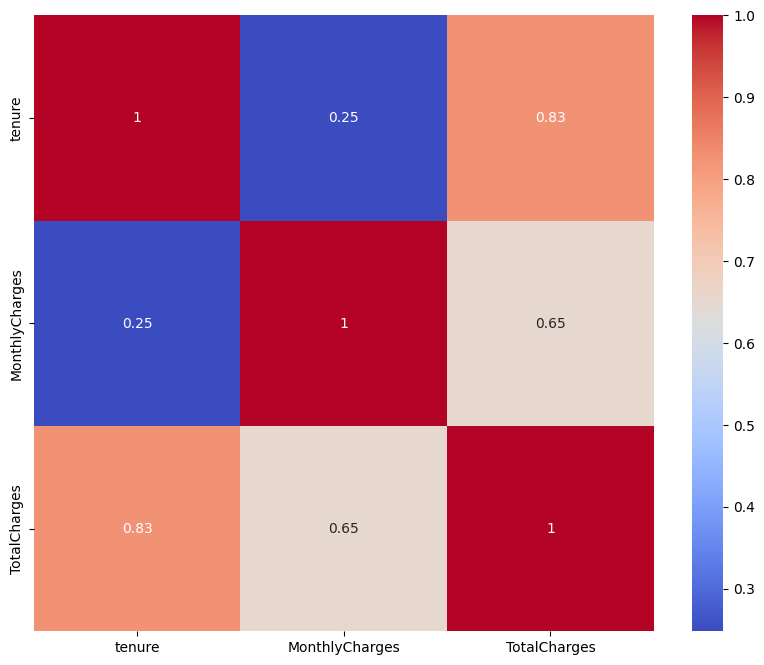

In [12]:

plt.figure(figsize=(10,8))
sns.heatmap(data[Num_features].corr(), annot=True, cmap='coolwarm')
plt.show()

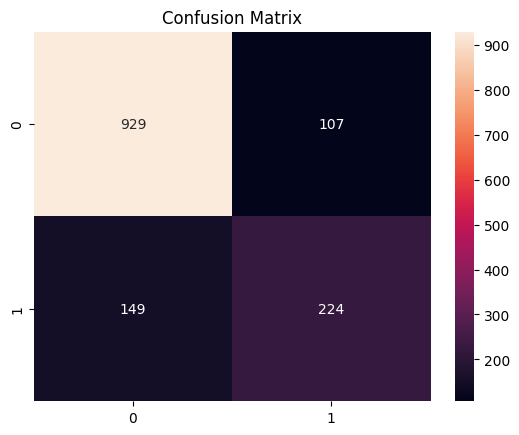

In [13]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

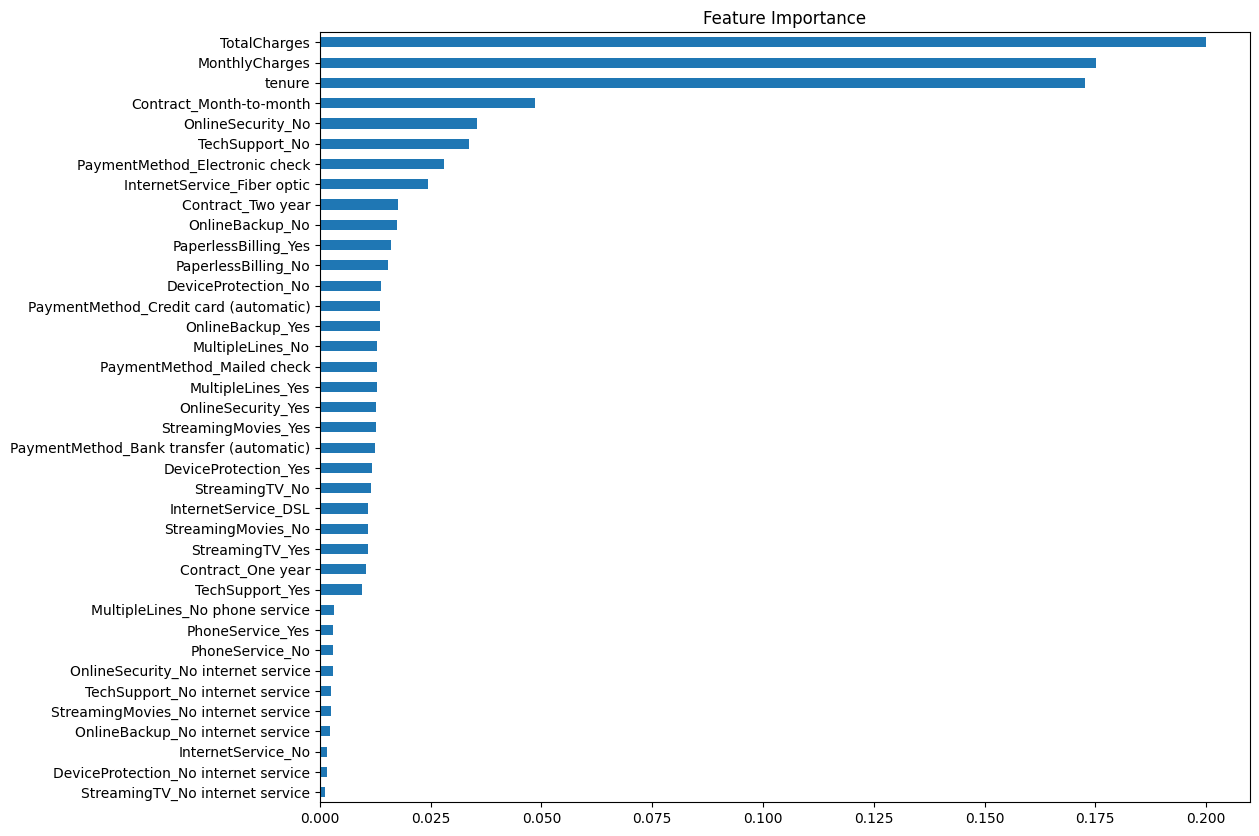

In [14]:

model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index=final_data.columns)

plt.figure(figsize=(12, 10))

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()